# 03 · EDA & Data Preparation (NHANES 2015–2018)

En este notebook se desarrolla la fase de **Exploratory Data Analysis (EDA)** y **Data Preparation** de CRISP-DM, utilizando como entrada los datasets filtrados:

- `set1_*` (ciclo 2015–2016)
- `set2_*` (ciclo 2017–2018)

Objetivos principales:

1. Unir DEMO, BMX y PAQ por ciclo (`set1_*`, `set2_*`) y concatenar ambos ciclos.
2. Calcular las variables objetivo:
   - `SBP_mean` (presión arterial sistólica promedio).
   - `DBP_mean` (presión arterial diastólica promedio).
   - `HTN_label` (hipertensión sí/no).
3. Realizar un EDA básico de distribuciones y valores perdidos.
4. Definir y aplicar una estrategia de imputación.
5. Dejar un dataset limpio listo para modelamiento supervisado y no supervisado.



In [1]:
!unzip processed_data.zip

Archive:  processed_data.zip
  inflating: set1_body_measurements.csv  
  inflating: set2_questionnaire.csv  
  inflating: set2_blood_pressure.csv  
  inflating: set1_questionnaire.csv  
  inflating: set2_demographic.csv    
  inflating: set1_blood_pressure.csv  
  inflating: set2_body_measurements.csv  
  inflating: set1_demographic.csv    


In [2]:
# 1. Importar librerías y definir rutas

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

BASE_PATH = Path(".")

PROCESSED_DIR = BASE_PATH / "data" / "processed"

print("Directorio de datos procesados:", PROCESSED_DIR.resolve())


Directorio de datos procesados: /content/data/processed


In [3]:
# 2. Cargar los sets filtrados (set1_* y set2_*)

set1_demographic = pd.read_csv(PROCESSED_DIR / "set1_demographic.csv")
set2_demographic = pd.read_csv(PROCESSED_DIR / "set2_demographic.csv")

set1_body_measurements = pd.read_csv(PROCESSED_DIR / "set1_body_measurements.csv")
set2_body_measurements = pd.read_csv(PROCESSED_DIR / "set2_body_measurements.csv")

set1_blood_pressure = pd.read_csv(PROCESSED_DIR / "set1_blood_pressure.csv")
set2_blood_pressure = pd.read_csv(PROCESSED_DIR / "set2_blood_pressure.csv")

set1_questionnaire = pd.read_csv(PROCESSED_DIR / "set1_questionnaire.csv")
set2_questionnaire = pd.read_csv(PROCESSED_DIR / "set2_questionnaire.csv")

for name, df in {
    "set1_demographic": set1_demographic,
    "set2_demographic": set2_demographic,
    "set1_body_measurements": set1_body_measurements,
    "set2_body_measurements": set2_body_measurements,
    "set1_blood_pressure": set1_blood_pressure,
    "set2_blood_pressure": set2_blood_pressure,
    "set1_questionnaire": set1_questionnaire,
    "set2_questionnaire": set2_questionnaire,
}.items():
    print(f"{name}: shape = {df.shape}")


set1_demographic: shape = (9971, 6)
set2_demographic: shape = (9254, 6)
set1_body_measurements: shape = (9544, 5)
set2_body_measurements: shape = (8704, 5)
set1_blood_pressure: shape = (9544, 9)
set2_blood_pressure: shape = (8704, 9)
set1_questionnaire: shape = (9255, 13)
set2_questionnaire: shape = (5856, 13)


In [4]:
# 3. Unir DEMO + BMX + PAQ por ciclo (usando SEQN como llave)

def merge_cycle(demo, bmx, paq, cycle_label):
    df = (
        demo
        .merge(bmx, on="SEQN", how="inner")
        .merge(paq, on="SEQN", how="left")
    )
    df["cycle"] = cycle_label
    return df

set1_merged = merge_cycle(set1_demographic, set1_body_measurements, set1_questionnaire, "2015_2016")
set2_merged = merge_cycle(set2_demographic, set2_body_measurements, set2_questionnaire, "2017_2018")

print("set1_merged:", set1_merged.shape)
print("set2_merged:", set2_merged.shape)

set1_merged.head()


set1_merged: (9544, 23)
set2_merged: (8704, 23)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,...,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,cycle
0,83732.0,1.0,62.0,3.0,5.0,4.39,94.8,184.5,27.8,101.1,...,NaN,NaN,2.0,NaN,NaN,1.0,6.0,30.0,480.0,2015_2016
1,83733.0,1.0,53.0,3.0,3.0,1.32,90.4,171.4,30.8,107.9,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,300.0,2015_2016
2,83734.0,1.0,78.0,3.0,3.0,1.51,83.4,170.1,28.8,116.5,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016
3,83735.0,2.0,56.0,3.0,5.0,5.00,109.8,160.9,42.4,110.1,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016
4,83736.0,2.0,42.0,4.0,4.0,1.23,55.2,164.9,20.3,80.4,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,540.0,2015_2016


### 3. Explicación

En esta sección se construye, para cada ciclo, una tabla analítica que contiene:

1. Variables demográficas (`DEMO`).
2. Medidas corporales (`BMX`).
3. Cuestionario de actividad física (`PAQ`).

Detalles:

- La unión se hace por `SEQN`:
  - `DEMO` ⨝ `BMX` con `how="inner"` para asegurar que haya información demográfica y antropométrica.
  - El `PAQ` se une con `how="left"`, aceptando missing en actividad física.
- Se agrega una columna `cycle` con los valores `"2015_2016"` y `"2017_2018"` para distinguir los ciclos.

El resultado son dos dataframes:

- `set1_merged` (ciclo 2015–2016).
- `set2_merged` (ciclo 2017–2018).


In [5]:
# 4. Concatenar ambos ciclos en un solo dataframe

df_adults = pd.concat([set1_merged, set2_merged], ignore_index=True)

print("df_adults (ambos ciclos):", df_adults.shape)
df_adults.head()


df_adults (ambos ciclos): (18248, 23)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,...,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,cycle
0,83732.0,1.0,62.0,3.0,5.0,4.39,94.8,184.5,27.8,101.1,...,NaN,NaN,2.0,NaN,NaN,1.0,6.0,30.0,480.0,2015_2016
1,83733.0,1.0,53.0,3.0,3.0,1.32,90.4,171.4,30.8,107.9,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,300.0,2015_2016
2,83734.0,1.0,78.0,3.0,3.0,1.51,83.4,170.1,28.8,116.5,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016
3,83735.0,2.0,56.0,3.0,5.0,5.00,109.8,160.9,42.4,110.1,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016
4,83736.0,2.0,42.0,4.0,4.0,1.23,55.2,164.9,20.3,80.4,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,540.0,2015_2016


In [6]:
# 5. Filtrar solo adultos (≥ 18 años)

print("Rango de RIDAGEYR antes del filtro:", df_adults["RIDAGEYR"].min(), "–", df_adults["RIDAGEYR"].max())

df_adults_examined = df_adults[df_adults["RIDAGEYR"] >= 18].copy()

print("df_adults_examined (solo adultos):", df_adults_examined.shape)
df_adults_examined[["SEQN", "RIDAGEYR"]].head()


Rango de RIDAGEYR antes del filtro: 5.397605346934028e-79 – 80.0
df_adults_examined (solo adultos): (11268, 23)


,SEQN,RIDAGEYR
0,83732.0,62.0
1,83733.0,53.0
2,83734.0,78.0
3,83735.0,56.0
4,83736.0,42.0


### 5. Explicación

Aunque en el Notebook 02 ya se definió conceptualmente que la unidad de análisis sería el **adulto**, el filtro se aplica aquí de forma explícita:

- Se mantiene únicamente a participantes con `RIDAGEYR ≥ 18`.
- El resultado se guarda en `df_adults_examined`.

Si posteriormente se decide incorporar una variable de estado de examen (por ejemplo, `RIDSTATR == 2` para “examinado en MEC”), el filtro adicional puede agregarse en este mismo paso.


In [7]:
# 6. Renombrar columnas a nombres más legibles

rename_map = {
    # DEMO
    "SEQN": "id",
    "RIDAGEYR": "age_years",
    "RIAGENDR": "gender_code",
    "RIDRETH3": "race_ethnicity_code",
    "DMDEDUC2": "education_level_code",
    "INDFMPIR": "income_poverty_ratio",
    # BMX
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm",
    "BMXBMI": "bmi",
    "BMXWAIST": "waist_cm",
    # PAQ - transporte
    "PAQ635": "transport_activity_code",
    "PAQ640": "transport_activity_days",
    "PAD645": "transport_activity_minutes",
    # PAQ - recreación vigorosa
    "PAQ650": "vigorous_recreation_code",
    "PAQ655": "vigorous_recreation_days",
    "PAD660": "vigorous_recreation_minutes",
    # PAQ - recreación moderada
    "PAQ665": "moderate_recreation_code",
    "PAQ670": "moderate_recreation_days",
    "PAD675": "moderate_recreation_minutes",
    # PAQ - trabajo
    "PAQ620": "work_activity_code",
    "PAD630": "work_activity_minutes",
    # PAQ - sedentarismo
    "PAD680": "sedentary_minutes",
}

df_adults_examined = df_adults_examined.rename(columns=rename_map)

print("Columnas después de renombrar:")
print(df_adults_examined.columns.tolist())
df_adults_examined.head()


Columnas después de renombrar:
['id', 'gender_code', 'age_years', 'race_ethnicity_code', 'education_level_code', 'income_poverty_ratio', 'weight_kg', 'height_cm', 'bmi', 'waist_cm', 'work_activity_code', 'work_activity_minutes', 'transport_activity_code', 'transport_activity_days', 'transport_activity_minutes', 'vigorous_recreation_code', 'vigorous_recreation_days', 'vigorous_recreation_minutes', 'moderate_recreation_code', 'moderate_recreation_days', 'moderate_recreation_minutes', 'sedentary_minutes', 'cycle']


,id,gender_code,age_years,race_ethnicity_code,education_level_code,income_poverty_ratio,weight_kg,height_cm,bmi,waist_cm,...,transport_activity_days,transport_activity_minutes,vigorous_recreation_code,vigorous_recreation_days,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_days,moderate_recreation_minutes,sedentary_minutes,cycle
0,83732.0,1.0,62.0,3.0,5.0,4.39,94.8,184.5,27.8,101.1,...,NaN,NaN,2.0,NaN,NaN,1.0,6.0,30.0,480.0,2015_2016
1,83733.0,1.0,53.0,3.0,3.0,1.32,90.4,171.4,30.8,107.9,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,300.0,2015_2016
2,83734.0,1.0,78.0,3.0,3.0,1.51,83.4,170.1,28.8,116.5,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016
3,83735.0,2.0,56.0,3.0,5.0,5.00,109.8,160.9,42.4,110.1,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016
4,83736.0,2.0,42.0,4.0,4.0,1.23,55.2,164.9,20.3,80.4,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,540.0,2015_2016


### 6. Explicación

Para facilitar el EDA, la interpretación y la posterior documentación, se renombraron las columnas de NHANES a nombres más descriptivos:

- Demografía:
  - `RIDAGEYR` → `age_years`
  - `RIAGENDR` → `gender_code`
  - `RIDRETH3` → `race_ethnicity_code`
  - `DMDEDUC2` → `education_level_code`
  - `INDFMPIR` → `income_poverty_ratio`
  - `SEQN` → `id`
- Antropometría:
  - `BMXWT` → `weight_kg`
  - `BMXHT` → `height_cm`
  - `BMXBMI` → `bmi`
  - `BMXWAIST` → `waist_cm`
- Actividad física:
  - Transporte: `PAQ635/PAQ640/PAD645` → `transport_activity_*`
  - Recreación vigorosa: `PAQ650/PAQ655/PAD660` → `vigorous_recreation_*`
  - Recreación moderada: `PAQ665/PAQ670/PAD675` → `moderate_recreation_*`
  - Trabajo: `PAQ620/PAD630` → `work_activity_*`
  - Sedentarismo: `PAD680` → `sedentary_minutes`

Este paso no cambia la información pero mejora la legibilidad del análisis.


In [8]:
# 7. Calcular SBP_mean, DBP_mean y HTN_label para cada ciclo a partir de BPX

SBP_COLS = ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]
DBP_COLS = ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]

def process_bpx(df_bpx):
    df = df_bpx.copy()

    sbp_cols = [c for c in SBP_COLS if c in df.columns]
    dbp_cols = [c for c in DBP_COLS if c in df.columns]

    # En NHANES, valores 0 suelen indicar medición no válida; se reemplazan por NaN antes de promediar
    df[sbp_cols] = df[sbp_cols].replace(0, np.nan)
    df[dbp_cols] = df[dbp_cols].replace(0, np.nan)

    df["SBP_mean"] = df[sbp_cols].mean(axis=1, skipna=True)
    df["DBP_mean"] = df[dbp_cols].mean(axis=1, skipna=True)

    # Definición de hipertensión (versión clásica ≥140/90).
    df["HTN_label"] = ((df["SBP_mean"] >= 140) | (df["DBP_mean"] >= 90)).astype("Int64")

    return df[["SEQN", "SBP_mean", "DBP_mean", "HTN_label"]].copy()

df_bpx_15_16_processed = process_bpx(set1_blood_pressure)
df_bpx_17_18_processed = process_bpx(set2_blood_pressure)

print("2015–2016 BPX processed:", df_bpx_15_16_processed.shape)
print("2017–2018 BPX processed:", df_bpx_17_18_processed.shape)

df_bpx_15_16_processed.head()


2015–2016 BPX processed: (9544, 4)
2017–2018 BPX processed: (8704, 4)


,SEQN,SBP_mean,DBP_mean,HTN_label
0,83732.0,122.666667,65.333333,0
1,83733.0,140.000000,86.000000,1
2,83734.0,135.333333,45.333333,0
3,83735.0,134.000000,70.000000,0
4,83736.0,104.000000,60.000000,0


### 7. Explicación

En esta celda se construyen las variables objetivo a partir de las lecturas crudas de BPX:

1. Se define una función `process_bpx` que:
   1. Identifica las columnas sistólicas (`BPXSY1–4`) y diastólicas (`BPXDI1–4`) disponibles.
   2. Reemplaza los valores `0` por `NaN`, ya que en NHANES suelen representar mediciones no válidas.
   3. Calcula:
      - `SBP_mean`: promedio de las lecturas sistólicas válidas.
      - `DBP_mean`: promedio de las lecturas diastólicas válidas.
   4. Define la etiqueta binaria `HTN_label`:
      - `1` si `SBP_mean ≥ 140` o `DBP_mean ≥ 90`.
      - `0` en caso contrario.
2. Se generan:
   - `df_bpx_15_16_processed` (2015–2016).
   - `df_bpx_17_18_processed` (2017–2018).
3. Solo se conservan las columnas `SEQN`, `SBP_mean`, `DBP_mean`, `HTN_label`.

Estos dataframes se unirán luego a la cohorte de adultos.


In [9]:
# 8. Concatenar BPX procesado de ambos ciclos y unir a df_adults_examined

df_bpx_processed = pd.concat(
    [df_bpx_15_16_processed, df_bpx_17_18_processed],
    ignore_index=True
)

print("df_bpx_processed:", df_bpx_processed.shape)
df_bpx_processed.head()


df_bpx_processed: (18248, 4)


,SEQN,SBP_mean,DBP_mean,HTN_label
0,83732.0,122.666667,65.333333,0
1,83733.0,140.000000,86.000000,1
2,83734.0,135.333333,45.333333,0
3,83735.0,134.000000,70.000000,0
4,83736.0,104.000000,60.000000,0


In [10]:
# 9. Unir BPX procesado con la cohorte de adultos (usando id/SEQN)

df_bpx_processed = df_bpx_processed.rename(columns={"SEQN": "id"})

df_adults_examined = df_adults_examined.merge(df_bpx_processed, on="id", how="left")

print("Shape de la cohorte final tras unir BPX:", df_adults_examined.shape)
df_adults_examined.head()


Shape de la cohorte final tras unir BPX: (11268, 26)


,id,gender_code,age_years,race_ethnicity_code,education_level_code,income_poverty_ratio,weight_kg,height_cm,bmi,waist_cm,...,vigorous_recreation_days,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_days,moderate_recreation_minutes,sedentary_minutes,cycle,SBP_mean,DBP_mean,HTN_label
0,83732.0,1.0,62.0,3.0,5.0,4.39,94.8,184.5,27.8,101.1,...,NaN,NaN,1.0,6.0,30.0,480.0,2015_2016,122.666667,65.333333,0
1,83733.0,1.0,53.0,3.0,3.0,1.32,90.4,171.4,30.8,107.9,...,NaN,NaN,2.0,NaN,NaN,300.0,2015_2016,140.000000,86.000000,1
2,83734.0,1.0,78.0,3.0,3.0,1.51,83.4,170.1,28.8,116.5,...,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016,135.333333,45.333333,0
3,83735.0,2.0,56.0,3.0,5.0,5.00,109.8,160.9,42.4,110.1,...,NaN,NaN,2.0,NaN,NaN,480.0,2015_2016,134.000000,70.000000,0
4,83736.0,2.0,42.0,4.0,4.0,1.23,55.2,164.9,20.3,80.4,...,NaN,NaN,2.0,NaN,NaN,540.0,2015_2016,104.000000,60.000000,0


In [11]:
# 10. EDA básico: resumen estadístico y distribuciones de las variables principales

numeric_cols = [
    "age_years", "income_poverty_ratio",
    "weight_kg", "height_cm", "bmi", "waist_cm",
    "transport_activity_minutes", "vigorous_recreation_minutes",
    "moderate_recreation_minutes", "work_activity_minutes",
    "sedentary_minutes",
    "SBP_mean", "DBP_mean",
]

df_adults_examined[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age_years,11268.0,48.918619,18.558700,1.800000e+01,33.000000,49.000000,64.000000,80.000000
income_poverty_ratio,9933.0,2.459958,1.606190,5.397605e-79,1.100000,2.040000,3.880000,5.000000
weight_kg,11110.0,81.894581,22.374603,3.240000e+01,66.200000,78.500000,93.600000,242.600000
height_cm,11117.0,166.250328,10.073340,1.297000e+02,158.800000,165.900000,173.600000,202.700000
bmi,11096.0,29.533769,7.268022,1.420000e+01,24.400000,28.400000,33.300000,86.200000
waist_cm,10552.0,99.860102,17.033379,5.640000e+01,87.700000,98.600000,110.025000,171.600000
transport_activity_minutes,2659.0,93.366679,582.569112,1.000000e+01,20.000000,30.000000,60.000000,9999.000000
vigorous_recreation_minutes,2823.0,82.574920,269.398326,1.000000e+01,40.000000,60.000000,120.000000,9999.000000
moderate_recreation_minutes,4526.0,74.674989,334.971311,1.000000e+01,30.000000,45.000000,60.000000,9999.000000
work_activity_minutes,4460.0,211.997085,639.495232,1.000000e+01,60.000000,120.000000,240.000000,9999.000000


In [17]:
df_adults_examined.dtypes

,0
id,float64
gender_code,float64
age_years,float64
race_ethnicity_code,float64
education_level_code,float64
income_poverty_ratio,float64
weight_kg,float64
height_cm,float64
bmi,float64
waist_cm,float64


In [12]:
# 11. EDA de valores perdidos (antes de imputar)

missing_counts = df_adults_examined.isnull().sum().sort_values(ascending=False)
missing_counts


,0
transport_activity_minutes,8609
transport_activity_days,8594
vigorous_recreation_minutes,8445
vigorous_recreation_days,8438
work_activity_minutes,6808
moderate_recreation_minutes,6742
moderate_recreation_days,6728
income_poverty_ratio,1335
waist_cm,716
education_level_code,529


### 11. Explicación

Se calcula el número de valores perdidos por columna usando:

- `df_adults_examined.isnull().sum()`

y se ordena de mayor a menor.

Este paso responde explícitamente a la pregunta:

> “¿En qué variables hay NaNs y en qué magnitud?”

A partir de esta salida se define la estrategia de imputación de la siguiente sección.


In [13]:
# pre-12. Limpieza de códigos especiales

import numpy as np

activity_minutes_cols = [
    "transport_activity_minutes",
    "vigorous_recreation_minutes",
    "moderate_recreation_minutes",
    "work_activity_minutes",
    "sedentary_minutes",
]

activity_days_cols = [
    "transport_activity_days",
    "vigorous_recreation_days",
    "moderate_recreation_days",
]

# 0.1 Reemplazar códigos especiales 7777/9999 por NaN en minutos y días
for col in activity_minutes_cols + activity_days_cols:
    if col in df_adults_examined.columns:
        df_adults_examined[col] = df_adults_examined[col].replace(
            {7777: np.nan, 9999: np.nan}
        )

# 0.2 Regla dura de plausibilidad: minutos > 1440 por día -> NaN
max_minutes_per_day = 1440
for col in activity_minutes_cols:
    if col in df_adults_examined.columns:
        df_adults_examined.loc[
            df_adults_examined[col] > max_minutes_per_day, col
        ] = np.nan

# 0.3 Reemplazar 'don't know' (9) con NaN en columnas de código de actividad
code_cols_to_nan = [
    "transport_activity_code",
    "vigorous_recreation_code",
    "moderate_recreation_code",
    "work_activity_code",
]
for col in code_cols_to_nan:
    if col in df_adults_examined.columns:
        df_adults_examined.loc[df_adults_examined[col] == 9, col] = np.nan

# 0.4 Reemplazar 'refused' (77) y 'don't know' (99) con NaN en columnas de días
days_cols_to_nan = [
    "vigorous_recreation_days",
    "transport_activity_days",
    "moderate_recreation_days",
]
for col in days_cols_to_nan:
    if col in df_adults_examined.columns:
        df_adults_examined.loc[
            df_adults_examined[col].isin([77, 99]), col
        ] = np.nan


In [14]:
# 12. Imputación de valores perdidos según tipo de variable

df_clean = df_adults_examined.copy()

# 12.1. Variables numéricas continuas: imputar con la mediana
num_median_cols = [
    "income_poverty_ratio",
    "weight_kg", "height_cm", "bmi", "waist_cm",
    "sedentary_minutes",
    "SBP_mean", "DBP_mean",
]

for col in num_median_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

# 12.2. Variables de duración / días de actividad física:
#       imputar con 0 (NA ≈ no realiza actividad)
activity_zero_cols = [
    "transport_activity_minutes", "transport_activity_days",
    "vigorous_recreation_minutes", "vigorous_recreation_days",
    "moderate_recreation_minutes", "moderate_recreation_days",
    "work_activity_minutes",
]

for col in activity_zero_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(0)

# 12.3. Variables categóricas: imputar con la moda
cat_mode_cols = [
    "education_level_code",
    "gender_code",
    "race_ethnicity_code",
    "transport_activity_code",
    "vigorous_recreation_code",
    "moderate_recreation_code",
    "work_activity_code",
]

for col in cat_mode_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode(dropna=True)[0]
        df_clean[col] = df_clean[col].fillna(mode_value)

# 12.4. Verificar que no queden NaNs en las columnas clave
print("Valores perdidos por columna después de imputar:")
print(df_clean.isnull().sum())


Valores perdidos por columna después de imputar:
id                             0
gender_code                    0
age_years                      0
race_ethnicity_code            0
education_level_code           0
income_poverty_ratio           0
weight_kg                      0
height_cm                      0
bmi                            0
waist_cm                       0
work_activity_code             0
work_activity_minutes          0
transport_activity_code        0
transport_activity_days        0
transport_activity_minutes     0
vigorous_recreation_code       0
vigorous_recreation_days       0
vigorous_recreation_minutes    0
moderate_recreation_code       0
moderate_recreation_days       0
moderate_recreation_minutes    0
sedentary_minutes              0
cycle                          0
SBP_mean                       0
DBP_mean                       0
HTN_label                      0
dtype: int64


In [15]:
#12.5 Re-evaluacion de datos unicos en busca de codigos especiales residuales

print("Valores únicos por columna en df_clean:")
for col in df_clean.columns:
    unique_count = df_clean[col].nunique(dropna=False) # Include NaN in count
    print(f"\nColumna '{col}':")
    print(f"  Número de valores únicos (incluyendo NaN): {unique_count}")

    # Mostrar los valores únicos si no son demasiados
    if unique_count <= 20 and unique_count > 0: # Avoid printing for all NaN columns unless necessary
        print(f"  Valores únicos: {df_clean[col].unique()}")
    elif unique_count > 20:
        print("  (Demasiados valores únicos para mostrar, mostrando los primeros 5)")
        print(f"  Primeros 5 valores únicos: {df_clean[col].unique()[:5]}")


Valores únicos por columna en df_clean:

Columna 'id':
  Número de valores únicos (incluyendo NaN): 11268
  (Demasiados valores únicos para mostrar, mostrando los primeros 5)
  Primeros 5 valores únicos: [83732. 83733. 83734. 83735. 83736.]

Columna 'gender_code':
  Número de valores únicos (incluyendo NaN): 2
  Valores únicos: [1. 2.]

Columna 'age_years':
  Número de valores únicos (incluyendo NaN): 63
  (Demasiados valores únicos para mostrar, mostrando los primeros 5)
  Primeros 5 valores únicos: [62. 53. 78. 56. 42.]

Columna 'race_ethnicity_code':
  Número de valores únicos (incluyendo NaN): 6
  Valores únicos: [3. 4. 1. 6. 7. 2.]

Columna 'education_level_code':
  Número de valores únicos (incluyendo NaN): 7
  Valores únicos: [5. 3. 4. 2. 1. 9. 7.]

Columna 'income_poverty_ratio':
  Número de valores únicos (incluyendo NaN): 487
  (Demasiados valores únicos para mostrar, mostrando los primeros 5)
  Primeros 5 valores únicos: [4.39 1.32 1.51 5.   1.23]

Columna 'weight_kg':
  Núm

### 12. Explicación

Se aplica una estrategia de imputación diferenciada según el tipo de variable:

1. **Variables numéricas continuas (mediana)**  
   - `income_poverty_ratio`, `weight_kg`, `height_cm`, `bmi`, `waist_cm`, `sedentary_minutes`, `SBP_mean`, `DBP_mean`.  
   - Se usa la **mediana** para reducir el impacto de outliers.

2. **Variables de minutos/días de actividad física (0)**  
   - `transport_activity_minutes/days`, `vigorous_recreation_*`, `moderate_recreation_*`, `work_activity_minutes`.  
   - Se imputan missing con **0**, interpretando `NaN` como “no realiza esa actividad de forma significativa”.

3. **Variables categóricas (moda)**  
   - `education_level_code`, `gender_code`, `race_ethnicity_code`, `*_activity_code`.  
   - Se imputan con la **moda** (valor más frecuente).

Al final se imprime nuevamente el conteo de `NaN` para verificar que no queden valores perdidos en las columnas relevantes. Si algún campo permanece con missing, puede requerir una decisión adicional (p. ej., eliminar esas filas o tratarlo de forma específica).


In [16]:
# 13.cambio de tipo de dato
int_cols = [
    "id",
    "gender_code",
    "race_ethnicity_code",
    "education_level_code",
    "transport_activity_code",
    "vigorous_recreation_code",
    "moderate_recreation_code",
    "work_activity_code",
    "HTN_label",
]

for col in int_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("int64")

df_clean["cycle"] = df_clean["cycle"].astype("category")


In [17]:
# 13.1 muestreo de cambio de tipo de dato
df_clean.dtypes

,0
id,int64
gender_code,int64
age_years,float64
race_ethnicity_code,int64
education_level_code,int64
income_poverty_ratio,float64
weight_kg,float64
height_cm,float64
bmi,float64
waist_cm,float64


In [18]:
# 13. Guardar dataset limpio para modelamiento supervisado

OUTPUT_DIR = BASE_PATH / "data" / "03_primary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

supervised_path = OUTPUT_DIR / "nhanes_supervised_dataset.csv"
df_clean.to_csv(supervised_path, index=False)

print("Dataset supervisado limpio guardado en:", supervised_path.resolve())


Dataset supervisado limpio guardado en: /content/data/03_primary/nhanes_supervised_dataset.csv


# **Gráficos de interés**

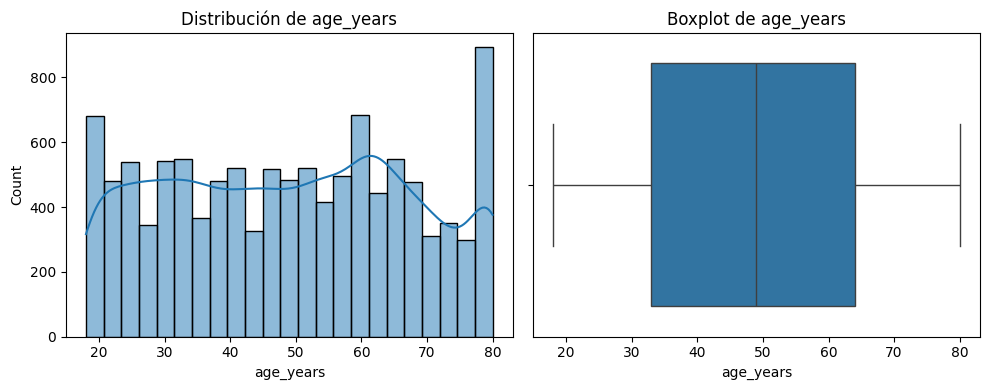

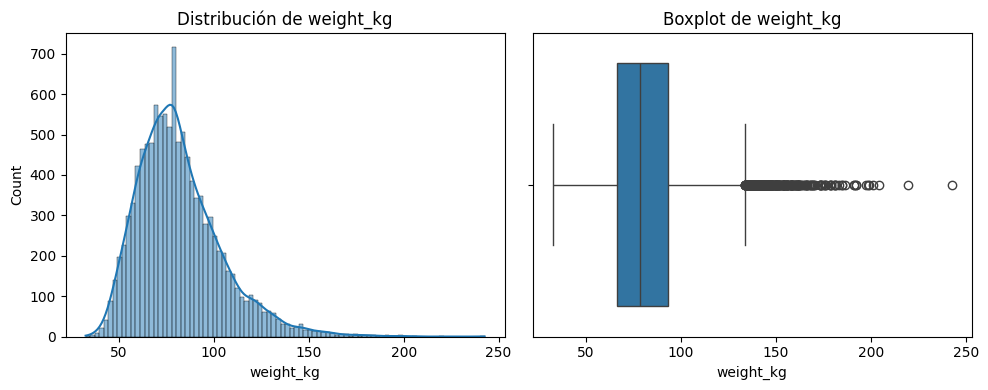

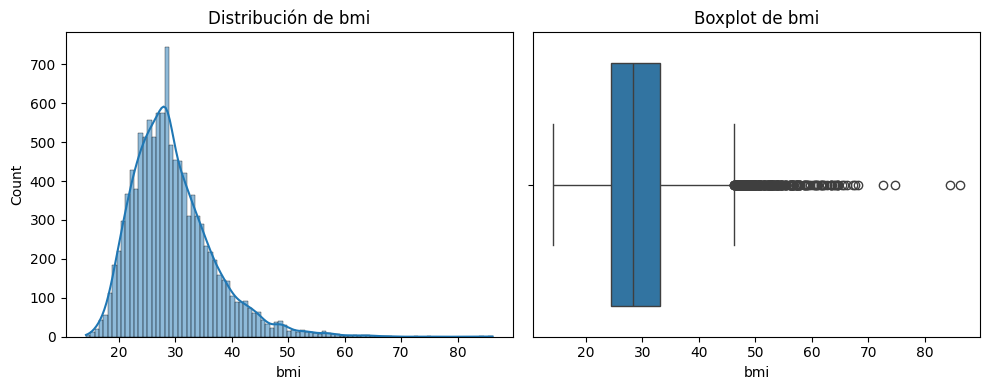

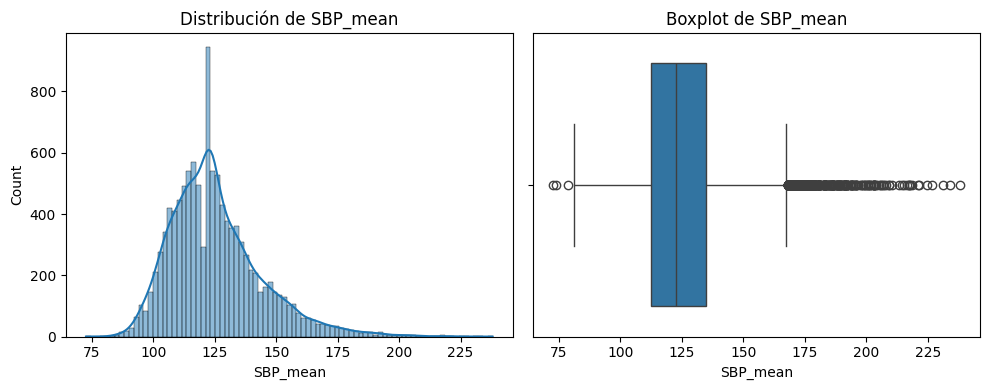

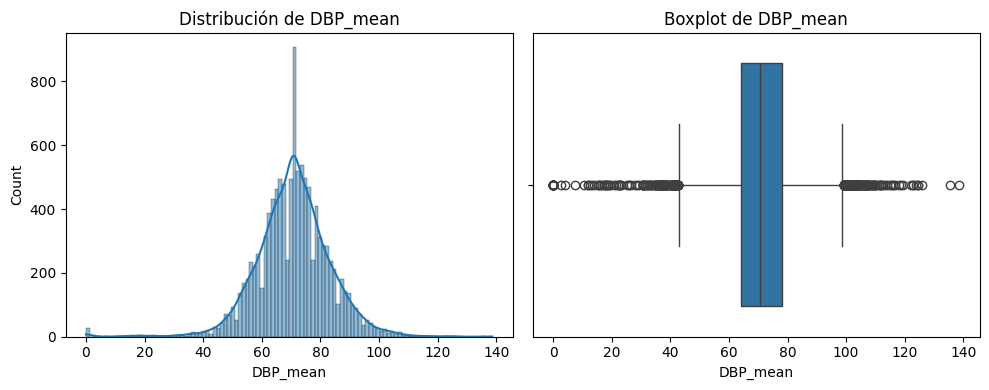

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["age_years", "weight_kg", "bmi", "SBP_mean", "DBP_mean"]

for col in num_cols:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribución de {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()


**Figura X. Distribución y boxplot del índice de masa corporal (bmi) y del peso (weight_kg).**

El índice de masa corporal muestra una distribución marcadamente asimétrica hacia la derecha, con una mediana en el rango de sobrepeso y una cola larga de valores elevados compatibles con obesidad severa y extrema. El boxplot identifica numerosos valores situados por encima del bigote superior, que corresponden a sujetos con IMC muy alto. De forma similar, la distribución del peso corporal presenta un rango amplio con presencia de individuos que alcanzan pesos muy elevados.

De acuerdo con la documentación oficial de NHANES para el componente de antropometría (ciclos 2017–2018), los rangos observados (IMC entre aproximadamente 12,3 y 86,2 kg/m² y peso entre 3,2 y 242,6 kg) son valores válidos y esperados en la población estudiada. Por tanto, aunque estos registros se comportan como outliers desde el punto de vista estadístico, se consideran observaciones reales y clínicamente relevantes, ya que representan individuos con obesidad extrema, un grupo de alto riesgo para el desarrollo de hipertensión arterial y otras enfermedades cardiovasculares.

https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm#BMXWT
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm#BMXBMI


/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


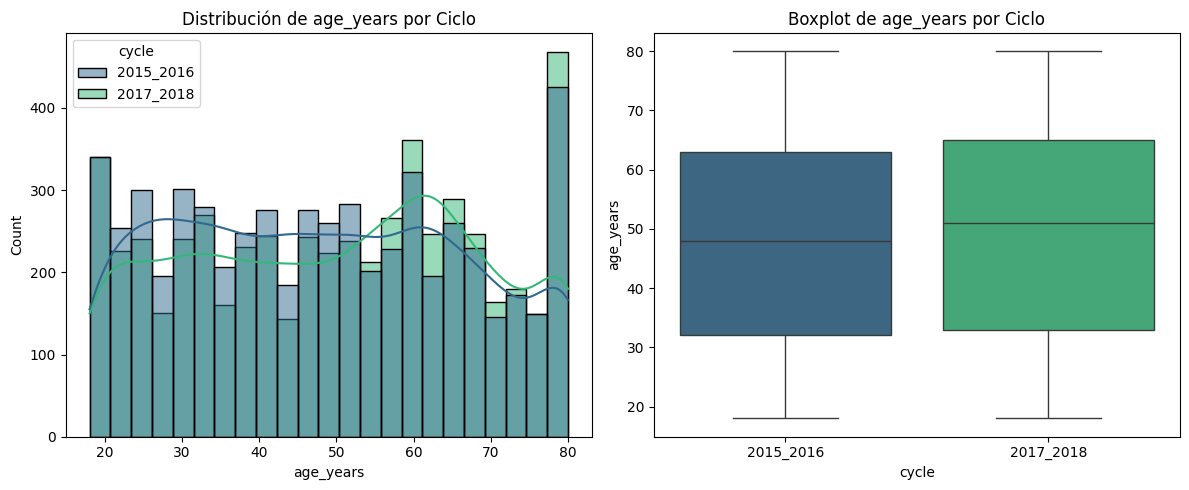

/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


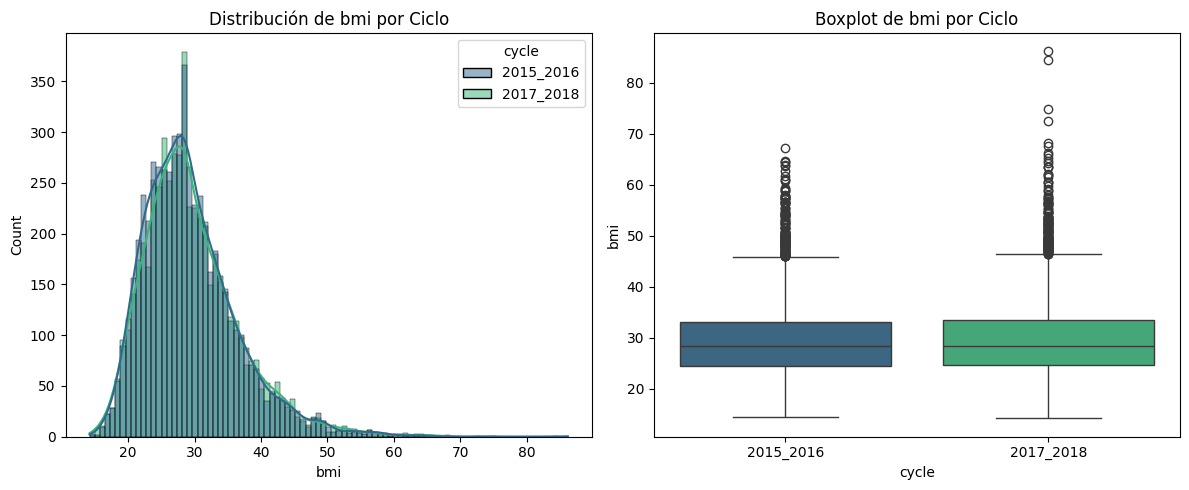

/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


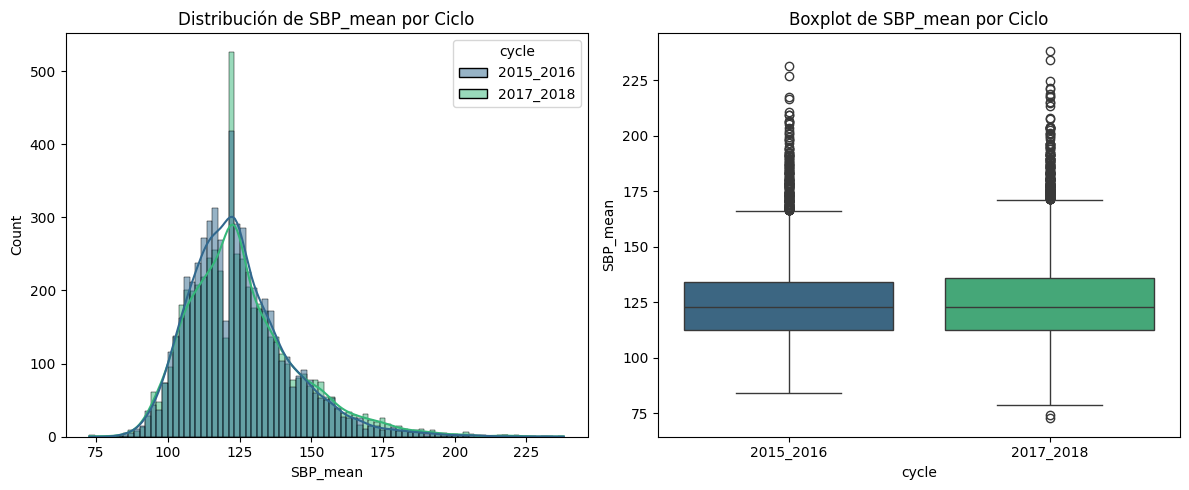

/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


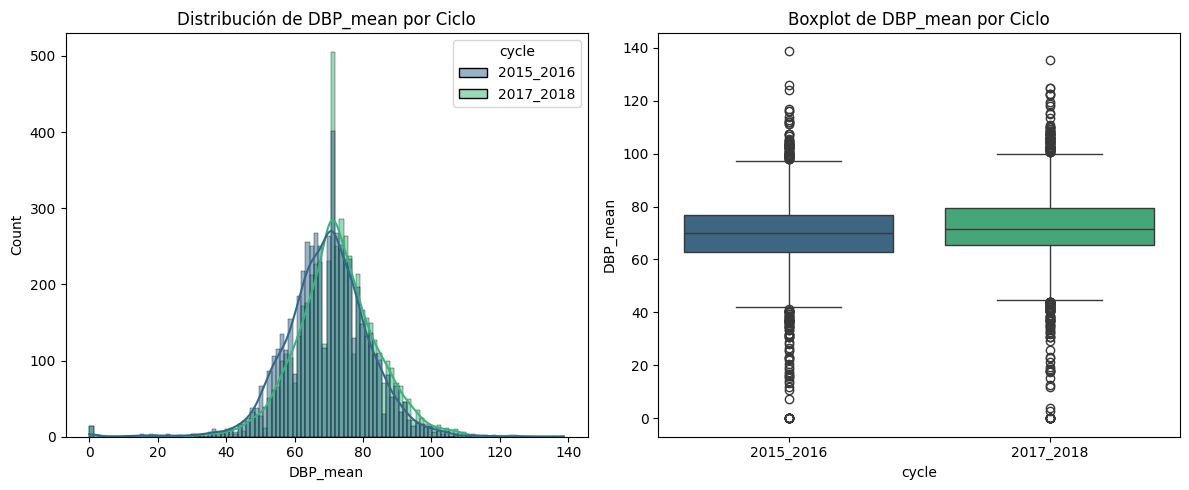

/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


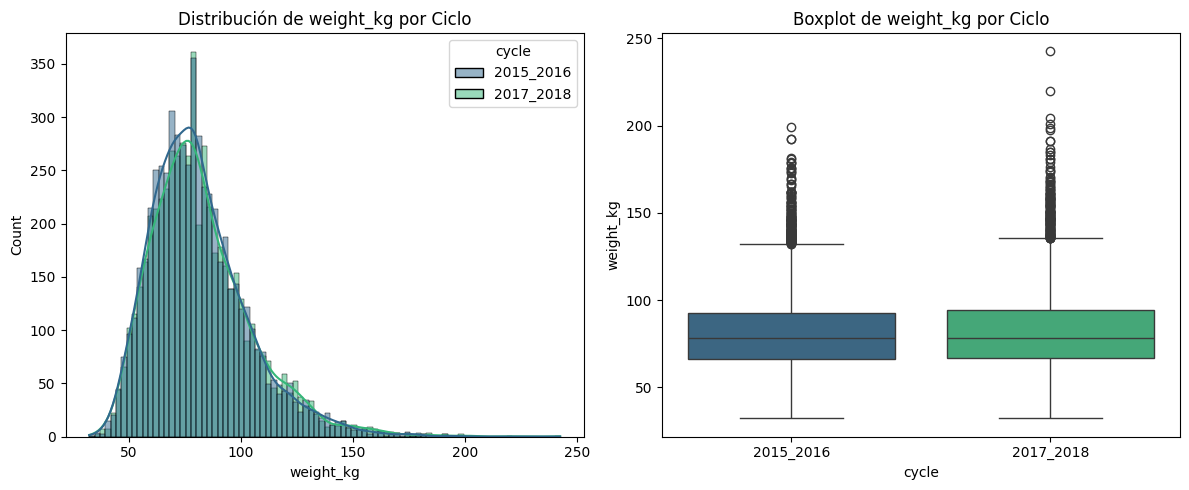

/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


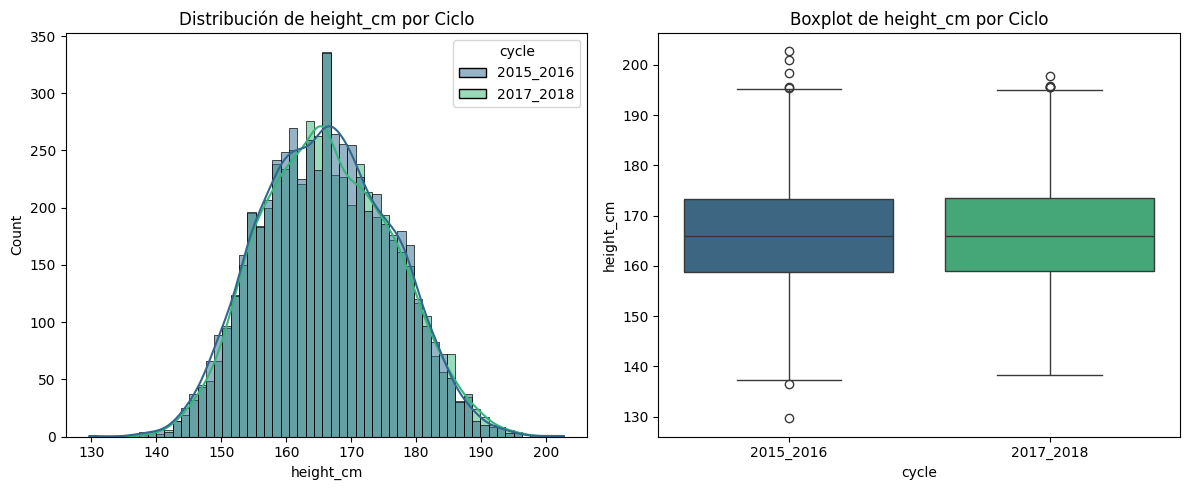

/tmp/ipython-input-1360232426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')


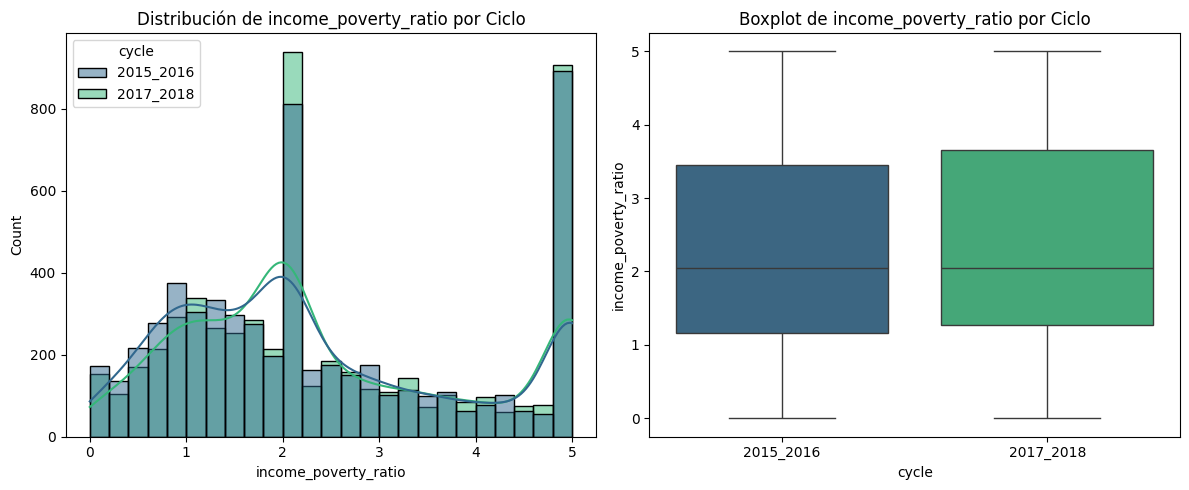

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos algunas columnas numéricas relevantes para comparar por ciclo
num_cols_to_compare = ["age_years", "bmi", "SBP_mean", "DBP_mean", "weight_kg", "height_cm", "income_poverty_ratio"]

for col in num_cols_to_compare:
    plt.figure(figsize=(12, 5))

    # Histograma para comparar distribuciones por ciclo
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_clean, x=col, hue='cycle', kde=True, palette='viridis')
    plt.title(f'Distribución de {col} por Ciclo')

    # Boxplot para comparar distribuciones por ciclo
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_clean, x='cycle', y=col, palette='viridis')
    plt.title(f'Boxplot de {col} por Ciclo')

    plt.tight_layout()
    plt.show()

## **Figura X. Comparación de variables antropométricas y de presión arterial según ciclo 2015–2016 y 2017–2018.**  

En ambos ciclos, la distribución de la edad (age_years) se extiende aproximadamente entre los 18 y los 80 años, con medianas y rangos intercuartílicos muy similares. No se observan diferencias relevantes en la estructura etaria de la muestra entre 2015–2016 y 2017–2018, lo que favorece la comparabilidad temporal.

El índice de masa corporal (bmi) presenta en los dos periodos una distribución marcadamente asimétrica hacia la derecha, con la mayoría de los participantes en el rango de sobrepeso y una cola prolongada hacia valores compatibles con obesidad severa y extrema. Las curvas de densidad y los boxplots muestran medianas prácticamente idénticas y un patrón de outliers altos muy parecido en ambos ciclos, lo que sugiere una carga estable de sobrepeso/obesidad en la población estudiada.

Las distribuciones de presión arterial sistólica media (SBP_mean) y diastólica media (DBP_mean) también son muy similares entre ciclos. La SBP_mean se concentra alrededor de 120–130 mmHg con una cola hacia valores altos, mientras que la DBP_mean se agrupa en torno a 70–80 mmHg con colas más moderadas. Los boxplots evidencian medianas y rangos intercuartílicos casi coincidentes, con un número comparable de valores extremos en ambos periodos, lo que indica que el perfil tensional basal de la muestra se mantiene estable en el tiempo.

En cuanto al peso corporal (weight_kg), se observa una distribución sesgada hacia la derecha en ambos ciclos, con gran parte de los sujetos en rangos intermedios y presencia de individuos con pesos elevados, incluyendo obesidad severa y extrema. La forma de las distribuciones y los boxplots son muy parecidos entre 2015–2016 y 2017–2018, sin cambios apreciables en la mediana ni en la dispersión. La talla (height_cm) muestra una distribución aproximadamente normal, con medianas y rangos intercuartílicos prácticamente idénticos entre ciclos y un número reducido de valores extremos.

En conjunto, estas figuras indican que la composición antropométrica (edad, talla, peso, índice de masa corporal) y el perfil de presión arterial de los participantes son muy homogéneos entre los ciclos 2015–2016 y 2017–2018. Esto sugiere que eventuales diferencias en la prevalencia de hipertensión entre periodos difícilmente se explicarán por cambios en la estructura básica de la población, sino por otros factores clínicos, conductuales o contextuales.


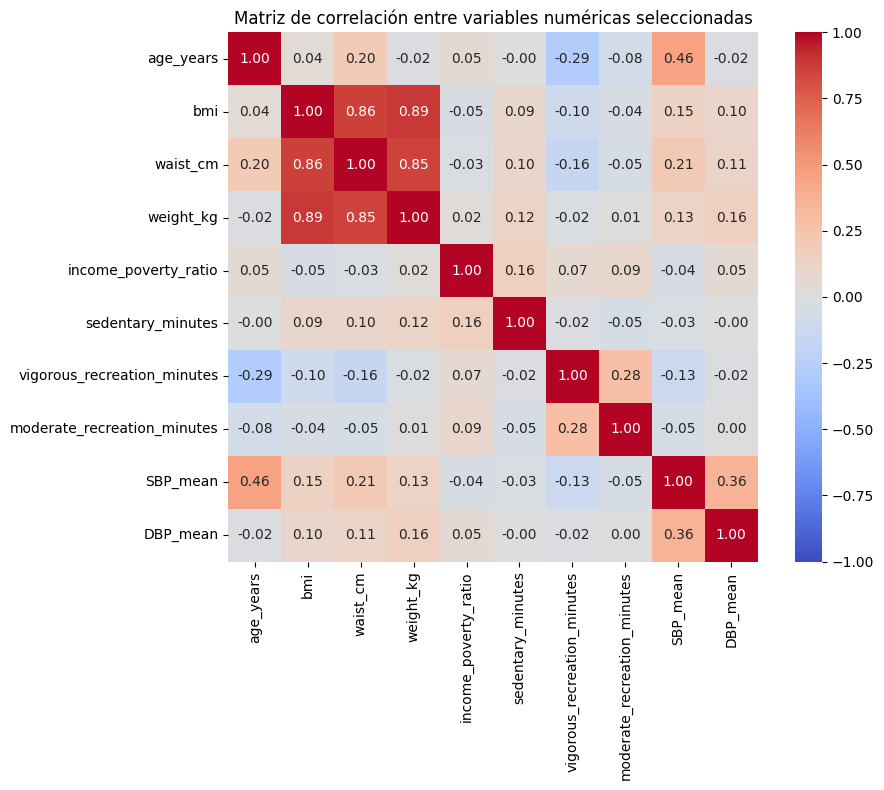

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionar columnas numéricas relevantes
cols_for_corr = [
    "age_years",
    "bmi",
    "waist_cm",
    "weight_kg",
    "income_poverty_ratio",
    "sedentary_minutes",
    "vigorous_recreation_minutes",
    "moderate_recreation_minutes",
    "SBP_mean",
    "DBP_mean",
]

# 2. Subset del dataframe
df_corr = df_clean[cols_for_corr]

# 3. Matriz de correlación de Pearson
corr_matrix = df_corr.corr(method="pearson")

# 4. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # muestra los coeficientes
    fmt=".2f",           # dos decimales
    cmap="coolwarm",     # paleta divergente
    vmin=-1, vmax=1,     # rango completo de correlación
    square=True
)
plt.title("Matriz de correlación entre variables numéricas seleccionadas")
plt.tight_layout()
plt.show()


## **Figura X. Matriz de correlación entre variables numéricas seleccionadas.**  

La matriz de correlación muestra una fuerte asociación positiva entre las variables antropométricas índice de masa corporal (bmi), perímetro de cintura (waist_cm) y peso corporal (weight_kg), con coeficientes superiores a 0,80, lo que indica una elevada redundancia entre estas medidas de tamaño corporal. La edad (age_years) se correlaciona de manera moderada con la presión arterial sistólica media (SBP_mean) (r ≈ 0,46) y prácticamente no se asocia con la presión diastólica media (DBP_mean), patrón coherente con el aumento preferente de la presión sistólica con la edad en adultos.

Las variables de actividad física y sedentarismo presentan correlaciones de pequeña magnitud con la presión arterial: los minutos de recreación vigorosa se asocian débilmente en sentido inverso con la edad y con la SBP_mean, mientras que los minutos sedentarios y de actividad moderada muestran relaciones muy discretas entre sí y con las presiones. El índice socioeconómico income_poverty_ratio exhibe correlaciones muy bajas con las demás variables, lo que sugiere que su relación con la hipertensión no es fuertemente lineal en este análisis crudo.

En conjunto, la figura confirma una alta colinealidad entre las medidas antropométricas y una asociación moderada entre edad y presión sistólica, mientras que la actividad física, el sedentarismo y el nivel socioeconómico muestran relaciones lineales más débiles con las presiones. Estos hallazgos orientan la selección y el tratamiento de las variables en los modelos de predicción de hipertensión.


# **Etapa de estandarización y normalización**

In [26]:
# 1. Seleccion de vairiables para procesar estandarización
from sklearn.preprocessing import StandardScaler

df_model_input = df_clean.copy()

cols_to_scale = [
    "age_years",
    "income_poverty_ratio",
    "weight_kg", "height_cm", "bmi", "waist_cm",
    "transport_activity_minutes", "transport_activity_days",
    "vigorous_recreation_minutes", "vigorous_recreation_days",
    "moderate_recreation_minutes", "moderate_recreation_days",
    "work_activity_minutes",
    "sedentary_minutes",
]

scaler = StandardScaler()
df_model_input[cols_to_scale] = scaler.fit_transform(df_model_input[cols_to_scale])

df_model_input.head()


,id,gender_code,age_years,race_ethnicity_code,education_level_code,income_poverty_ratio,weight_kg,height_cm,bmi,waist_cm,...,vigorous_recreation_days,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_days,moderate_recreation_minutes,sedentary_minutes,cycle,SBP_mean,DBP_mean,HTN_label
0,83732,1,0.704896,3,5,1.307607,0.582950,1.824479,-0.237956,0.080069,...,-0.508399,-0.448176,1,2.228154,0.093001,0.643800,2015_2016,122.666667,65.333333,0
1,83733,1,0.219927,3,3,-0.720051,0.384928,0.515166,0.177939,0.492555,...,-0.508399,-0.448176,2,-0.686614,-0.535054,-0.258061,2015_2016,140.000000,86.000000,1
2,83734,1,1.567064,3,3,-0.594561,0.069894,0.385234,-0.099325,1.014228,...,-0.508399,-0.448176,2,-0.686614,-0.535054,0.643800,2015_2016,135.333333,45.333333,0
3,83735,2,0.381584,3,5,1.710497,1.258025,-0.534283,1.786068,0.626006,...,-0.508399,-0.448176,2,-0.686614,-0.535054,0.643800,2015_2016,134.000000,70.000000,0
4,83736,2,-0.372813,4,4,-0.779494,-1.199247,-0.134493,-1.277695,-1.175587,...,-0.508399,-0.448176,2,-0.686614,-0.535054,0.944420,2015_2016,104.000000,60.000000,0


In [28]:
# 1) Verificar que solo cambiaron las columnas definidas
changed_cols = [
    c for c in df_model_input.columns
    if not df_model_input[c].equals(df_clean[c])
]
print("Columnas cambiadas:", changed_cols)

# 2) Media y desviación estándar de las columnas escaladas
df_model_input[cols_to_scale].mean().round(4)
df_model_input[cols_to_scale].std().round(4)

# 3) Comparar un ejemplo concreto
col = "age_years"
print("Original:", df_clean[col].iloc[:5].values)
print("Escalado:", df_model_input[col].iloc[:5].values)


Columnas cambiadas: ['age_years', 'income_poverty_ratio', 'weight_kg', 'height_cm', 'bmi', 'waist_cm', 'work_activity_minutes', 'transport_activity_days', 'transport_activity_minutes', 'vigorous_recreation_days', 'vigorous_recreation_minutes', 'moderate_recreation_days', 'moderate_recreation_minutes', 'sedentary_minutes']
Original: [62. 53. 78. 56. 42.]
Escalado: [ 0.70489643  0.21992715  1.56706404  0.38158358 -0.37281308]


Se utiliza StandardScaler (media 0, desviación estándar 1) para:

* evitar que variables en minutos (0–1000+) dominen sobre otras de escala pequeña (ej. IMC 20–60),

* permitir comparar modelos lineales y KNN/SVM en una escala homogénea.

No se escalan los targets (SBP_mean, HTN_label) para mantener interpretabilidad

## **Análisis para selección de features**

In [30]:
feature_cols = [
    # numéricas continuas (ya escaladas en Kedro, aquí en EDA puedes usar df_model_input)
    "age_years",
    "income_poverty_ratio",
    "weight_kg",
    "height_cm",
    "bmi",
    "waist_cm",
    "transport_activity_minutes",
    "transport_activity_days",
    "vigorous_recreation_minutes",
    "vigorous_recreation_days",
    "moderate_recreation_minutes",
    "moderate_recreation_days",
    "work_activity_minutes",
    "sedentary_minutes",
    # categóricas codificadas
    "gender_code",
    "race_ethnicity_code",
    "education_level_code",
    "transport_activity_code",
    "vigorous_recreation_code",
    "moderate_recreation_code",
    "work_activity_code",
]

target_reg = "SBP_mean"
target_clf = "HTN_label"


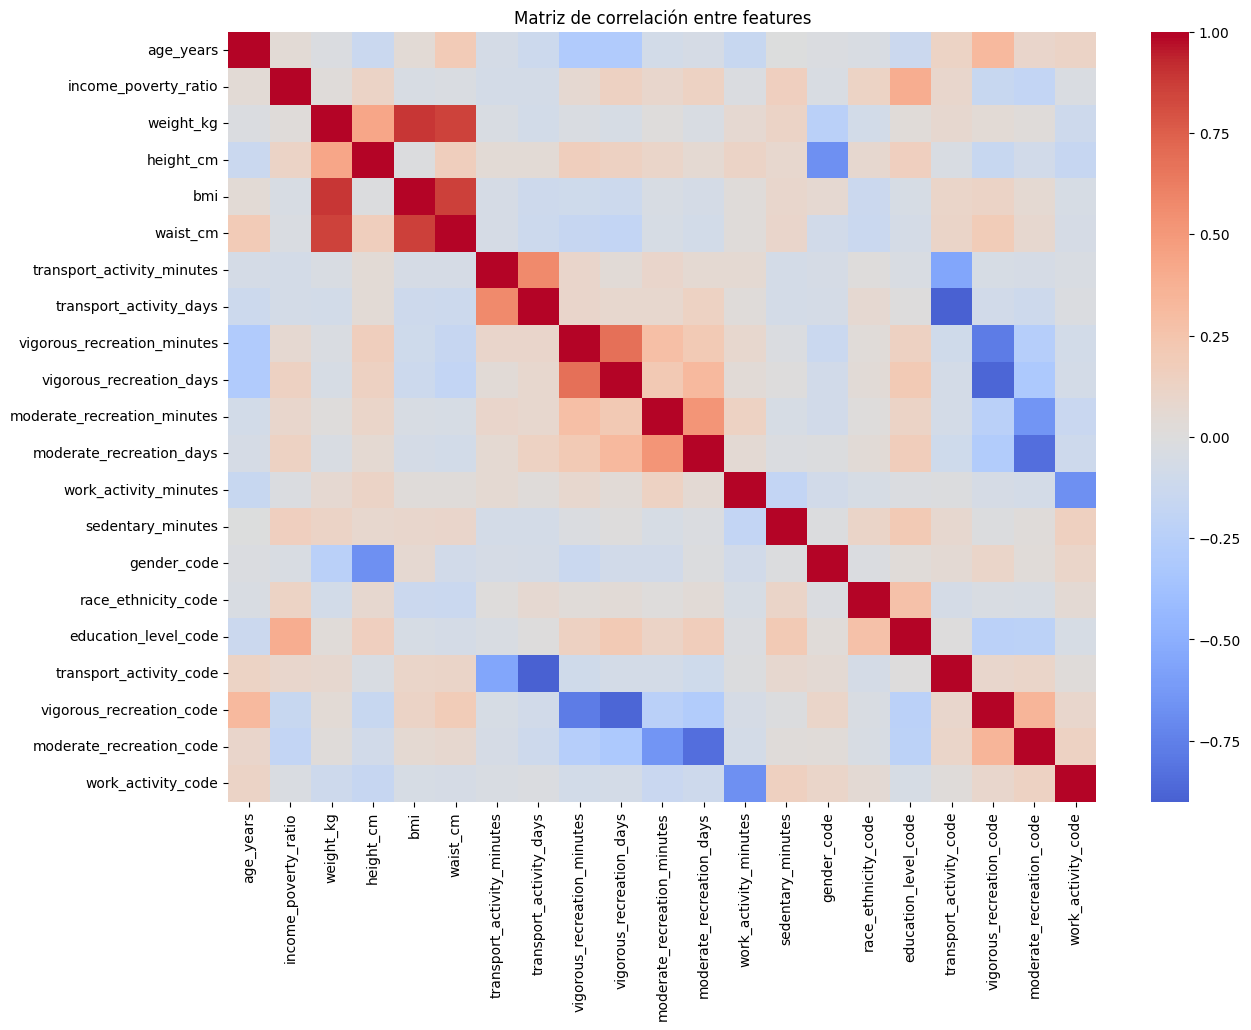

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_model_input[feature_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre features")
plt.show()


In [32]:
corr_with_sbp = df_model_input[feature_cols].corrwith(df_model_input[target_reg])
corr_with_sbp.sort_values(ascending=False)


,0
age_years,0.460482
waist_cm,0.214257
vigorous_recreation_code,0.177533
bmi,0.146871
weight_kg,0.126076
moderate_recreation_code,0.073365
work_activity_code,0.052051
transport_activity_code,0.034160
race_ethnicity_code,-0.002236
transport_activity_minutes,-0.009796


In [33]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

X = df_model_input[feature_cols]
y_reg = df_model_input[target_reg]
y_clf = df_model_input[target_clf]

mi_reg = mutual_info_regression(X, y_reg, random_state=42)
mi_clf = mutual_info_classif(X, y_clf, random_state=42)

mi_reg_series = pd.Series(mi_reg, index=feature_cols).sort_values(ascending=False)
mi_clf_series = pd.Series(mi_clf, index=feature_cols).sort_values(ascending=False)

mi_reg_series
mi_clf_series


,0
age_years,0.073807
vigorous_recreation_code,0.012184
vigorous_recreation_minutes,0.011923
income_poverty_ratio,0.010992
waist_cm,0.010228
education_level_code,0.009294
work_activity_code,0.005063
moderate_recreation_code,0.003989
vigorous_recreation_days,0.003982
transport_activity_minutes,0.003614


## Resultados

A partir de la matriz de correlación se identificó un bloque de alta colinealidad entre weight_kg, height_cm, bmi y waist_cm. Para reducir redundancia sin perder información clínica, se decidió conservar únicamente bmi y waist_cm, eliminando weight_kg y height_cm del conjunto final de predictores

Se mantuvieron todas las variables demográficas y socioeconómicas (age_years, gender_code, race_ethnicity_code, education_level_code, income_poverty_ratio) por su relevancia clínica y epidemiológica, pese a que algunas presenten asociaciones más débiles con la presión arterial

Entonces, donde la única asociación realmente fuerte es con la edad (r ≈ 0,48), seguida de cintura e IMC; esto encaja bastante bien con lo esperado clínicamente.

Es por esto que, más que depender de la correlación marginal, se evaluará la relevancia de cada variable en el contexto de modelos multivariados (regresión y clasificación), examinando importancia de variables e impacto sobre las métricas de desempeño (RMSE, R², AUC).”